In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os


os.chdir("/home/philbou/projects/def-rfajber/philbou/analysis_paper1")

import diagnostic_plot_helper as dps  
from scipy.special import gamma
import gc
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
from matplotlib import cm
from matplotlib.colors import ListedColormap


def get_global_2D(term,area):
    # term is (time,lat,lon)
    twoD_avg = dps.area_w_avg(area, term, D3=True) # (time)
    time_2D_avg = np.mean(twoD_avg,axis = 0)
    return time_2D_avg

def decomp_term_time_2D_vert(term,area,phalf,ps,temp):
    # term is (time,pfull,lat,lon)
    vert_avg = dps.vertical_int_z(term,temp, phalf,ps) # (time,lat,lon)
    vert_2D_avg = dps.area_w_avg(area, vert_avg, D3=True) # (time)
    time_vert_2D_avg = np.mean(vert_2D_avg,axis = 0)
    
    prime = term - time_vert_2D_avg
    return term,time_vert_2D_avg,prime

def decomp_term_time_2D(term,area):
    # term is (time,lat,lon)
    twoD_avg = dps.area_w_avg(area, term, D3=True) # (time)
    time_2D_avg = np.mean(twoD_avg,axis = 0)
    
    prime = term - time_2D_avg
    return term,time_2D_avg,prime

def decomp_term_time(term):
    # term is (time,pfull,lat,lon)

    time_avg = term.mean(dim = "time")
    
    prime = term - time_avg
    return term,time_avg,prime

def get_eddy_kin_energy(ucomp,vcomp):
    u,global_u,u_prime = decomp_term_time(ucomp)
    v,global_v,v_prime = decomp_term_time(vcomp)
    uterm = (u_prime**2).mean(dim = "time",keepdims=True)
    vterm = (v_prime**2).mean(dim = "time",keepdims=True)
    return 0.5* (uterm + vterm)

def gamma_dist(x,mean,mom2):
    theta = (mom2-mean**2)/(mean)
    alpha = mean/theta
    num = x**(alpha -1) * np.exp(-x/theta)
    den = gamma(alpha) * theta**alpha
    return num/den

def weibull_dist(x,mean,mom2):
    std = np.sqrt(mom2-mean**2)
    b_ = (mean/std)**1.086
    a_ = mean/(gamma(1+1/b_))
    return (b_/a_)*(x/a_)**(b_-1)*np.exp(-(x/a_)**b_)

def get_alpha_theta(mean,mom2):
    theta = (mom2-mean**2)/(mean)
    alpha = mean/theta
    return alpha, theta

def get_a_b(mean,mom2):
    std = np.sqrt(mom2-mean**2)
    b_ = (mean/std)**1.086
    a_ = mean/(gamma(1+1/b_))
    return a_, b_

def get_n_moment_weib(a,b,n):
    return a**n * gamma(1 + (n/b))

def get_n_moment_gamma(alpha, theta, n):
    return theta**n * gamma(alpha+n)/gamma(alpha)

path_cur = "/home/philbou/projects/def-rfajber/philbou/analysis_paper1/Figures"

land_mask_name = "era_land_t42.nc"
land_bool = True
if land_bool:
    lm_path = "/home/philbou/Isca/exp/test_cases/wv_age/input/"+land_mask_name
    ds_landmask = xr.open_dataset(lm_path) 
    land_mask = ds_landmask.land_mask.values
    
plt.rcParams['text.usetex'] = True

# Load and process datasets
delta_sst_values = np.array([0,2])
ds_dict = {}
i=0
for delta_sst in delta_sst_values:
    path_folder = "~/projects/def-rfajber/philbou/saved_ds/"
    #path_folder = "./"
    base_folder_name = "RT42_sst_"


    exp_folder_name = f"{base_folder_name}{'m' + str(abs(delta_sst)) if delta_sst < 0 else str(delta_sst)}_bucket"
    path = f"{path_folder}/{exp_folder_name}"

    ds_age = xr.open_dataset(f"{path}/age.nc")
    ds_mix = xr.open_dataset(f"{path}/mixed_layer.nc",decode_times = False)
    ds_dyn = xr.open_dataset(f"{path}/dynamics.nc")
    ds_atm = xr.open_dataset(f"{path}/atmosphere.nc")
    ds_precip_age = xr.open_dataset(f"{path}/precipitation_age.nc")

    ds_rad = xr.open_dataset(f"{path}/rrtm_rad.nc")

    ds_age["time"] = np.arange(0,len(ds_age.time.values),1)
    ds_dyn["time"] = np.arange(0,len(ds_dyn.time.values),1)
    ds_rad["time"] = np.arange(0,len(ds_rad.time.values),1)
    ds_atm["time"] = np.arange(0,len(ds_atm.time.values),1)
    ds_mix["time"] = np.arange(0,len(ds_mix.time.values),1)
    ds_precip_age["time"] = np.arange(0,len(ds_precip_age.time.values),1)
    
    area = dps.get_area(ds_age)
    
    ts = ds_mix.t_surf.values
    time_global_ts = dps.area_w_avg(area,np.mean(ts, axis=0))
    temp = ds_dyn.temp
    q = ds_age.sphum
    sphum = ds_age.sphum
    qmoments = [ds_age.sphum_age_1,ds_age.sphum_age_2]
    moments = [qmoments[0]/sphum,qmoments[1]/sphum]
    central_moments = [moments[0], moments[1]-moments[0]**2]

    mean = moments[0]
    ps = ds_age.ps

    psint = ds_age.ps.mean(dim= "time").values
    pfull = ds_age.pfull
    phalf = 100*ds_age.phalf.values
    lat = ds_age.lat
    lon = ds_age.lon
    pot_temp = dps.get_pot_temp(temp,pfull,ps)
    pot_temp_zonal = np.mean(np.mean(pot_temp,axis = 0),axis = 2)
    std = central_moments[1]**(1/2)

    b = (mean/std)

    a = mean/(gamma(1+1/b))
    
    v_age = dps.vertical_int_moist(moments[0].values,q,phalf,psint)
    v_age_time = np.mean(v_age,axis =0)/(24*60**2)

    v_shape = dps.vertical_int_moist(b.values,q,phalf,psint)
    v_shape_time = np.mean(v_shape,axis =0)
    
    v_std = dps.vertical_int_moist(std.values,q,phalf,psint)
    v_std_time = np.mean(v_std,axis =0)
    
    da = ds_precip_age.precip_age
    masked = da.where(da != 0)
    precip_age = masked.mean(dim="time", skipna=True)
    
    tropopause_height = dps.tropopause_height(pfull.values,phalf/100,temp.mean(dim = "time").values,lat.values)
    ts_global = get_global_2D(ts,area)
    
    
    tmp_dic = {
        'delta_sst_model': delta_sst,
        'ds_age': ds_age,
        'ds_dyn': ds_dyn,
        'ds_atm': ds_atm,
        'ds_rad': ds_rad,
        'ds_mix': ds_mix,
        'ds_precip_age' : ds_precip_age,
        'global_surf_temp': time_global_ts,
        "temp": temp,
        "q": q,
        "sphum": sphum,
        "qmoments": qmoments,
        "moments": moments,
        "central_moments": central_moments,
        "mean": mean,
        "ps": ps,
        "pfull": pfull,
        "phalf": phalf,
        "lat": lat,
        "lon": lon,
        "pot_temp": pot_temp,
        "pot_temp_zonal": pot_temp_zonal,
        "std": std,
        "shape": b,
        "a": a,
        "ts_global" : ts_global,
        "tropopause_height": tropopause_height,
        "precip_age" : precip_age,
        "vert_time_mean" : v_age_time,
        "vert_time_shape" : v_shape_time,
        "v_std_time" : v_std_time
    }

    ds_data_6h = xr.open_dataset(f"{path}/data_6h.nc")
    ds_data_6h["time"] = np.arange(0,len(ds_data_6h.time.values),1)
    tmp_dic['ds_data_6h'] = ds_data_6h
    tmp_dic['ds_data_6h'] = ds_data_6h
        
    ds_dict[str(delta_sst)] = tmp_dic
    del ds_dyn, ds_mix,delta_sst, ds_age, time_global_ts, temp, lon,q, sphum, qmoments, moments, central_moments, mean, ps, pfull, lat, pot_temp, pot_temp_zonal, std, b, a,v_shape_time,v_age_time
    gc.collect()


control_sst_val = ds_dict['0']['ts_global']
delta_sst_exact = ds_dict['2']['ts_global'] - control_sst_val

anomaly_mean = (ds_dict['2']["mean"]  - ds_dict['0']["mean"])/delta_sst_exact
anomaly_std = (ds_dict['2']["std"]  - ds_dict['0']["std"])/delta_sst_exact
anomaly_shape = (ds_dict['2']["shape"]  - ds_dict['0']["shape"])/delta_sst_exact
anomaly_vert_mean = (ds_dict['2']["vert_time_mean"]  - ds_dict['0']["vert_time_mean"])/delta_sst_exact
anomaly_vert_shape = (ds_dict['2']["vert_time_shape"]  - ds_dict['0']["vert_time_shape"])/delta_sst_exact

rel_anomaly_mean = 100*(ds_dict['2']["mean"]  - ds_dict['0']["mean"])/ds_dict['0']["mean"]/delta_sst_exact
rel_anomaly_std = 100*(ds_dict['2']["std"]  - ds_dict['0']["std"])/ds_dict['0']["std"]/delta_sst_exact
rel_anomaly_shape = 100*(ds_dict['2']["shape"]  - ds_dict['0']["shape"])/ds_dict['0']["shape"]/delta_sst_exact
rel_anomaly_vert_mean = 100*(ds_dict['2']["vert_time_mean"]  - ds_dict['0']["vert_time_mean"])/ds_dict['0']["vert_time_mean"]/delta_sst_exact
rel_anomaly_vert_shape = 100*(ds_dict['2']["vert_time_shape"]  - ds_dict['0']["vert_time_shape"])/ds_dict['0']["vert_time_shape"]/delta_sst_exact

mean = ds_dict['2']["mean"]
shape = ds_dict['0']["shape"]
std = ds_dict['0']["std"]
lat = ds_dict['0']["lat"]
lon = ds_dict['0']["lon"]
pot_temp_zonal = ds_dict['0']["pot_temp_zonal"]
pot_temp_zonal2 = ds_dict['2']["pot_temp_zonal"]
ps = ds_dict['0']["ps"]
pfull = ds_dict['0']["pfull"]

trop_h_0 = ds_dict["0"]["tropopause_height"]
trop_h_2 = ds_dict['2']["tropopause_height"]

zonal_ps = ps.mean(dim=["time", "lon"]) / 100  # still an xarray.DataArray

# Assuming pfull has dim ("plev")
# We want to compare pfull with zonal_ps (dims: lat)
mask2 = pfull > zonal_ps  # xarray will broadcast to (plev, lat)



# Apply mask directly to your data
mask = mask2.broadcast_like(shape.mean(dim = ["time","lon"]))
#trop_h_m2 = ds_dict["-2"]["tropopause_height"]
"""
delta_sst_exact_4 = ds_dict['2']['ts_global'] - control_sst_val

anomaly_mean_4 = (ds_dict['2']["mean"]  - ds_dict['0']["mean"])/delta_sst_exact_4
anomaly_std_4 = (ds_dict['2']["std"]  - ds_dict['0']["std"])/delta_sst_exact_4
anomaly_shape_4 = (ds_dict['2']["shape"]  - ds_dict['0']["shape"])/delta_sst_exact_4
anomaly_vert_mean_4 = (ds_dict['2']["vert_time_mean"]  - ds_dict['0']["vert_time_mean"])/delta_sst_exact_4
anomaly_vert_shape_4 = (ds_dict['2']["vert_time_shape"]  - ds_dict['0']["vert_time_shape"])/delta_sst_exact_4

rel_anomaly_mean_4 = 100 * (ds_dict['2']["mean"]  - ds_dict['0']["mean"]) / ds_dict['0']["mean"] / delta_sst_exact_4
rel_anomaly_std_4 = 100 * (ds_dict['2']["std"]  - ds_dict['0']["std"]) / ds_dict['0']["std"] / delta_sst_exact_4
rel_anomaly_shape_4 = 100 * (ds_dict['2']["shape"]  - ds_dict['0']["shape"]) / ds_dict['0']["shape"] / delta_sst_exact_4
rel_anomaly_vert_mean_4 = 100 * (ds_dict['2']["vert_time_mean"]  - ds_dict['0']["vert_time_mean"]) / ds_dict['0']["vert_time_mean"] / delta_sst_exact_4
rel_anomaly_vert_shape_4 = 100 * (ds_dict['2']["vert_time_shape"]  - ds_dict['0']["vert_time_shape"]) / ds_dict['0']["vert_time_shape"] / delta_sst_exact_4

trop_h_4 = ds_dict["4"]["tropopause_height"]
trop_h_m4 = ds_dict["-4"]["tropopause_height"]
"""

FileNotFoundError: [Errno 2] No such file or directory: '/home/philbou/projects/def-rfajber/philbou/saved_ds/RT42_sst_0_bucket/mixed_layer.nc'

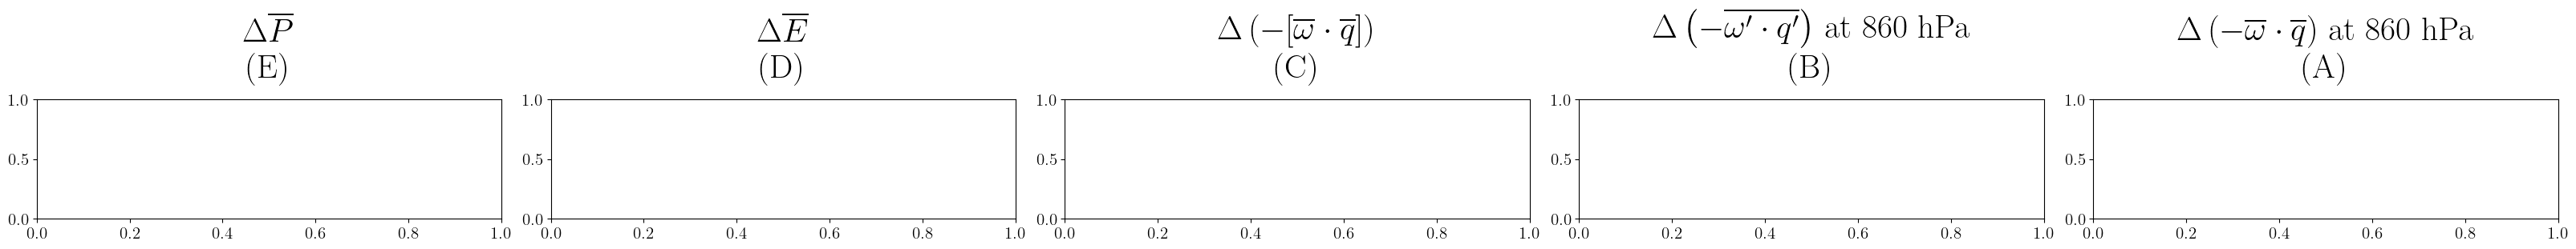

In [7]:
fig, axs = plt.subplots(1,5,figsize = (32,3),constrained_layout=True)
axs[0].set_title("$\\Delta \\overline{P}$ \n (E)",pad = 20,fontsize = 30)
axs[1].set_title("$\\Delta \\overline{E}$ \n (D)",pad = 20,fontsize = 30)
axs[2].set_title("$\\Delta \\left(-[\\overline{\\omega} \\cdot \\overline{q}]\\right)$ \n (C)",pad = 20,fontsize = 30)
axs[3].set_title("$\\Delta \\left(-\\overline{\\omega' \\cdot q'}\\right)$ at 860 hPa \n (B)",pad = 20,fontsize = 30)
axs[4].set_title("$\\Delta \\left(-\\overline{\\omega} \\cdot \\overline{q}\\right)$ at 860 hPa \n (A)",pad = 20,fontsize = 30)
plt.savefig("titles.png",dpi = 350)

In [ ]:
anomaly_mean = (ds_dict['2']["mean"]  - ds_dict['0']["mean"])/delta_sst_exact

#anomaly_mean1 = (ds_dict['1']["mean"]  - ds_dict['0']["mean"])/(ds_dict['1']['ts_global'] - control_sst_val)

In [ ]:
sink0 = ds_dict["0"]["ds_age"].dt_sink
q0 = ds_dict["0"]["q"]
sink2 = ds_dict['2']["ds_age"].dt_sink
q2 = ds_dict['2']["q"]

dq_conv0  = ds_dict["0"]["ds_age"].dt_qg_convection
dq_cond0  = ds_dict["0"]["ds_age"].dt_qg_condensation

dq_conv2  = ds_dict['2']["ds_age"].dt_qg_convection
dq_cond2  = ds_dict['2']["ds_age"].dt_qg_condensation

In [ ]:
rh0 = ds_dict["0"]["ds_atm"].rh
rh2 = ds_dict['2']["ds_atm"].rh

In [ ]:
omegaq0 = ds_dict["0"]["ds_dyn"].omega.mean("time") * q0.mean("time")

omegaq2 = ds_dict["2"]["ds_dyn"].omega.mean("time") * q2.mean("time")

In [ ]:
pa = ds_dict["0"]["ds_precip_age"]
ds_age =ds_dict["0"]["ds_age"]
precip = ds_age.precipitation

In [ ]:
"""fig,ax = plt.subplots(1,2,figsize = (22,8),gridspec_kw={'hspace': 0.3,'wspace': 0.05})

ax_sink = ax[0]
fig_,ax_sink,cb = dps.plot_age_moments_vertical_profile(100,rh0 * (24*60**2),1,ps,pfull,lat,mask,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "YlGnBu",
                                                    time_avg = True,lnP=False,custom = True, ax = ax_sink,steps=26,min_val = 0,ext = "both")
ax_sink.set_title("RH [$\\%$]\n (A)",pad = 20,fontsize = 30)
ax_sink = ax[1]
fig_,ax_sink,cb = dps.plot_age_moments_vertical_profile(100,1e3*(rh2-rh0)/rh0/delta_sst_exact * (24*60**2),1,ps,pfull,lat,mask,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "BrBG",
                                                    time_avg = True,lnP=False,custom = True, ax = ax_sink,steps=26,min_val = -100,ext = "both")
ax_sink.set_title("$\\Delta RH$ [$\\% K^{-1}$]\n (B)",pad = 20,fontsize = 30)
ax_sink.set_ylabel(" ")
for axi in ax:
    axi.set_ylim(975,100)
fig.savefig(f"{path_cur}/rh.png",dpi = 250 )"""
"""fig,ax = plt.subplots(1,2,figsize = (22,8),gridspec_kw={'hspace': 0.3,'wspace': 0.05})

ax_sink = ax[0]
fig_,ax_sink,cbar = dps.plot_age_moments_vertical_profile(3,1e3*dq_conv0 * (24*60**2)**2,1,ps,pfull,lat,mask,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "Spectral",
                                                    time_avg = True,lnP=False,custom = True, ax = ax_sink,steps=31,min_val = -3,ext = "both")
ax_sink.set_title("$dq_{conv}$ [$g\\cdot kg^{-1}\\cdot $day$^{-1}$]\n (A)",pad = 20,fontsize = 30)
ax_sink = ax[1]
ig_,ax_sink,cbar = dps.plot_age_moments_vertical_profile(1.5,1e3*dq_cond0 * (24*60**2)**2,1,ps,pfull,lat,mask,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "Spectral",
                                                    time_avg = True,lnP=False,custom = True, ax = ax_sink,steps=31,min_val = -1.5,ext = "both")
ax_sink.set_title("$dq_{cond}$ [$g\\cdot kg^{-1}\\cdot $day$^{-1}$]\n (B)",pad = 20,fontsize = 30)
ax_sink.set_ylabel(" ")
for axi in ax:
    axi.set_ylim(975,10)"""

"""fig,ax = plt.subplots(1,2,figsize = (22,8),gridspec_kw={'hspace': 0.3,'wspace': 0.05})

ax_sink = ax[0]
fig_,ax_sink,c = dps.plot_age_moments_vertical_profile(3,100*1e3*dq_conv0 * (24*60**2)**2,1,ps,pfull,lat,mask,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "Spectral",
                                                    time_avg = True,lnP=False,custom = True, ax = ax_sink,steps=31,min_val = -3,ext = "both")
ax_sink.set_title("$dq_{conv}$ [$g\\cdot kg^{-1}\\cdot $day$^{-1}$]\n (A)",pad = 20,fontsize = 30)
ax_sink = ax[1]
fig_,ax_sink,c = dps.plot_age_moments_vertical_profile(1.5,100*1e3*dq_cond0 * (24*60**2)**2,1,ps,pfull,lat,mask,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "Spectral",
                                                    time_avg = True,lnP=False,custom = True, ax = ax_sink,steps=31,min_val = -1.5,ext = "both")
ax_sink.set_title("$dq_{cond}$ [$g\\cdot kg^{-1}\\cdot $day$^{-1}$]\n (B)",pad = 20,fontsize = 30)
ax_sink.set_ylabel(" ")
for axi in ax:
    axi.set_ylim(975,10)
fig.savefig(f"{path_cur}/dq_cond_cond.png",dpi = 250 )"""
"""fig,ax = plt.subplots(1,2,figsize = (22,8),gridspec_kw={'hspace': 0.3,'wspace': 0.05})

ax_sink = ax[0]
fig_,ax_sink,c = dps.plot_age_moments_vertical_profile(3/4,(1e3*dq_conv2-1e3*dq_conv0) * (24*60**2)**2,1,ps,pfull,lat,mask,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "BrBG",
                                                    time_avg = True,lnP=False,custom = True, ax = ax_sink,steps=31,min_val = -3/4,ext = "both")
ax_sink.set_title("$dq_{conv}$ [$g\\cdot kg^{-1}\\cdot $day$^{-1}$]\n (A)",pad = 20,fontsize = 30)
ax_sink = ax[1]
fig_,ax_sink,c = dps.plot_age_moments_vertical_profile(1.5/4,(1e3*dq_cond2-1e3*dq_cond0) * (24*60**2)**2,1,ps,pfull,lat,mask,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "BrBG",
                                                    time_avg = True,lnP=False,custom = True, ax = ax_sink,steps=31,min_val = -1.5/4,ext = "both")
ax_sink.set_title("$dq_{cond}$ [$g\\cdot kg^{-1}\\cdot $day$^{-1}$]\n (B)",pad = 20,fontsize = 30)
ax_sink.set_ylabel(" ")
for axi in ax:
    axi.set_ylim(975,100)
fig.savefig(f"{path_cur}/dq_cond_cond_anomaly.png",dpi = 250 )"""
"""
fig,ax = plt.subplots(1,2,figsize = (22,8),gridspec_kw={'hspace': 0.3,'wspace': 0.05})

ax_sink = ax[0]
fig_,ax_sink,c = dps.plot_age_moments_vertical_profile(1.5,1e3*(q2-q0) * (24*60**2)/delta_sst_exact,1,ps,pfull,lat,mask,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "PuOr_r",
                                                    time_avg = True,lnP=False,custom = True, ax = ax_sink,steps=26,min_val = -1.5,ext = "neither",theta = True)

ax_sink.set_title("$q$ [$g\\cdot kg^{-1}\\cdot K^{-1}$]\n       (A)", pad=20, fontsize=30)
ax_sink = ax[1]
fig_,ax_sink,c = dps.plot_age_moments_vertical_profile(0.25,-1e3*(sink2-sink0) * (24*60**2)**2/delta_sst_exact,1,ps,pfull,lat,mask,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "PuOr_r",
                                                    time_avg = True,lnP=False,custom = True, ax = ax_sink,steps=26,min_val = -0.25,ext = "max")
ax_sink.set_title("$S^-$ [$g\\cdot kg^{-1}\\cdot $day$^{-1}\\cdot K^{-1}$]\n       (B)",pad = 20,fontsize = 30)
ax_sink.set_ylabel(" ")
for axi in ax:
    axi.set_ylim(975,100)
#fig.suptitle("Anomally",fontsize = 35,y = 1.06)
fig.savefig(f"{path_cur}/qsink_anomaly.png",dpi = 250 )"""

Figure 1

In [ ]:
ucomp0 = ds_dict['0']['ds_dyn'].ucomp
vcomp0 = ds_dict['0']['ds_dyn'].vcomp
omega0 = ds_dict['0']['ds_dyn'].omega
q0_m = ds_dict['0']['ds_age'].sphum
q2_m = ds_dict['2']['ds_age'].sphum
latb = ds_dict['0']['ds_age'].latb


ds_6h0 = ds_dict['0']['ds_data_6h']
q0 = ds_6h0.sphum
v0 = ds_6h0.vcomp
u0 = ds_6h0.ucomp
omega0 = ds_6h0.omega

qprime0 = q0 - q0.mean(dim = ["time"])
vprime0 = v0 - v0.mean(dim = ["time"])
uprime0 = u0 - u0.mean(dim = ["time"])
omegaprime0 = omega0 - omega0.mean(dim = ["time"])
vqprime0_time = np.mean(vprime0 * qprime0,axis = 0)


vq_time0 = np.mean(v0,axis=0) * np.mean(q0,axis=0)

eddykin0 =  0.5 *(uprime0**2 + vprime0**2)
vert_eddykin0 = dps.vertical_int(eddykin0.values,phalf,psint)
eddykin0_time =  0.5 * ((uprime0**2).mean(dim = ["time"]) + (vprime0**2).mean(dim = ["time"]))

ucomp2 = ds_dict['2']['ds_dyn'].ucomp
vcomp2 = ds_dict['2']['ds_dyn'].vcomp
omega2 = ds_dict['2']['ds_dyn'].omega
q2 = ds_dict['2']['ds_age'].sphum
latb = ds_dict['2']['ds_age'].latb


qvcomp2 = vcomp2 * q2
ds_6h2 = ds_dict['2']['ds_data_6h']
q2 = ds_6h2.sphum
v2 = ds_6h2.vcomp
u2 = ds_6h2.ucomp
omega2 = ds_6h2.omega
qprime2 = q2 - q2.mean(dim = ["time"])
vprime2 = v2 - v2.mean(dim = ["time"])
uprime2 = u2 - u2.mean(dim = ["time"])
omegaprime2 = omega2 - omega2.mean(dim = ["time"])
vqprime2_time = np.mean(vprime2 * qprime2,axis = 0)

vq_time2 = np.mean(v2,axis=0) * np.mean(q2,axis=0)

eddykin2 =  0.5 *(uprime2**2 + vprime2**2)
vert_eddykin2 = dps.vertical_int(eddykin2.values,phalf,psint)
eddykin2_time =  0.5 * ((uprime2**2).mean(dim = ["time"]) + (vprime2**2).mean(dim = ["time"]))


In [ ]:
"""
def seasonal_avg(da):
    # Split into years
    N = int(da.shape[0]/5)
    years = [da[i*N:(i+1)*N,:,:,:] for i in range(5)]
    JJA_arr = []
    DJF_arr = []
    for i in range(5):
        year = years[i]
        print(year.shape)
        reshaped = arr.reshape(12, 5)  # 12 groups of 5
        averaged = reshaped.mean(axis=1)
        
        JJA = np.mean(year.values[5:8,:,:,:],axis = 0)
        JJA_arr.append(JJA)
        DJF = np.mean(year.values[-1:1,:,:,:],axis = 0)
        DJF_arr.append(DJF)

    JJA_arr = np.array(JJA_arr)
    DJF_arr = np.array(DJF_arr)
    JJA_val = np.mean(JJA_arr,axis = 0)
    DJF_val = np.mean(DJF_arr,axis = 0)
    return DJF_val[np.newaxis,:,:,:],JJA_val[np.newaxis,:,:,:]
    
q0_m_DJF , q0_m_JJA = seasonal_avg(q0_m)

rh0_DJF , rh0_JJA = seasonal_avg(rh0)
sink0_DJF , sink0_JJA = seasonal_avg(sink0)


v0_DJF , v0_JJA = seasonal_avg(v0)
q0_DJF , q0_JJA = seasonal_avg(q0)


vq_time0_DJF = np.mean(v0_DJF,axis=0) * np.mean(q0_DJF,axis=0)
vq_time0_JJA = np.mean(v0_JJA,axis=0) * np.mean(q0_JJA,axis=0)

eddykin0_time_DJF =  0.5 * ((uprime0_DJF**2).mean(dim = ["time"]) + (vprime0_DJF**2).mean(dim = ["time"]))
eddykin0_time_JJA =  0.5 * ((uprime0_JJA**2).mean(dim = ["time"]) + (vprime0_JJA**2).mean(dim = ["time"]))

vqprime0_time_DJF = np.mean(vprime0_DJF * qprime0_DJF,axis = 0)
"""

In [ ]:
full_cmap = plt.get_cmap('Spectral_r')

# Extract bottom half by resampling
bottom_half_cmap = mcolors.LinearSegmentedColormap.from_list(
    'Spectral_bottom_half',
    full_cmap(np.linspace(0.5, 1, 256))  # 0 to 0.5 is the bottom half
)

In [ ]:
fig, ax = plt.subplots(3,2,figsize = (22,26),constrained_layout=True)
ax_sink = ax[0,0]

fig_,ax_sink,cbar = dps.plot_age_moments_vertical_profile(15,1e3*q0_m * (24*60**2),1,ps,pfull,lat,mask,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "YlGnBu",
                                                    time_avg = True,lnP=False,custom = True, ax = ax_sink,steps=16,min_val = 0,ext = "max",theta = False)
ax_sink.set_title("$[\\overline{q}]$\n       (A)", pad=20, fontsize=30)

ax_sink.plot(lat,zonal_ps/100)

cbar.set_label("$g\\cdot kg^{-1}$",fontsize = 25,labelpad = 5)

ax_sink = ax[0,1]
fig_,ax_sink,cbar = dps.plot_age_moments_vertical_profile(100,rh0 * (24*60**2),1,ps,pfull,lat,mask,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "YlGnBu",
                                                    time_avg = True,lnP=False,custom = True, ax = ax_sink,steps=26,min_val = 0,ext = "max",theta = False)
ax_sink.set_title("$[\\overline{RH}]$ \n       (B)", pad=20, fontsize=25)
isentropic_levels = np.arange(250, 390, 20)
cs=ax_sink.contour(lat, pfull, pot_temp_zonal,colors="white",levels = isentropic_levels)
plt.clabel(cs, inline=True, fontsize=14)  
cbar.set_label("$\\%$",fontsize = 25,labelpad = 5)

ax_sink = ax[1,0]
fig_,ax_sink,cbar = dps.plot_age_moments_vertical_profile(0,1e3*sink0 * (24*60**2)**2,1,ps,pfull,lat,mask,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "YlGnBu_r",
                                                    time_avg = True,lnP=False,custom = True, ax = ax_sink,steps=16,min_val = -3,ext = "min",theta = False)
ax_sink.set_title("$[\\overline{S^-}]$ \n       (C)",pad = 20,fontsize = 30)
ax_sink.set_ylabel(" ")
cbar.set_label("$g\\cdot kg^{-1}\\cdot $day$^{-1}$",fontsize = 25,labelpad = 5)
    
ax_v = ax[1,1]

from matplotlib.colors import SymLogNorm

cbar = dps.plot_vertical_profile(1e3*np.mean(vq_time0,axis = 2),lat,pfull,ax_v,"Spectral_r",mask,level_space=np.linspace(-12.5,12.5,25),contours=False,lnP = False,
                          theta = False,thetac="",pot_temp_zonal=None,extend = "both")

ax_v.set_title("$[\\overline{v}\\cdot\\overline{q}]$ \n     (D)",fontsize = 30,pad = 20)
ax_v.set_xlabel(" ")
ax_v.set_ylabel(" ")
cbar.set_label("$g \\cdot kg^{-1} \\cdot m \\cdot s^{-1}$",fontsize = 25,labelpad = 5)

ax_vp = ax[2,0]
# Define dense log-like contour levels
linthresh = 1e-6
vmax = 12.5
vmin = -vmax

# Log-spaced levels
n_levels = 26
log_pos = np.logspace(np.log10(linthresh), np.log10(vmax), n_levels//2)
log_neg = -log_pos[::-1]
levels = np.concatenate([log_neg, [0], log_pos])

# Symmetric log normalization
norm = SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax, base=10)

cbar = dps.plot_vertical_profile(1e3*np.mean(vqprime0_time,axis = 2),lat,pfull,ax_vp,"Spectral_r",mask,norm=False,level_space = np.linspace(-12.5,12.5,25),contours=False,lnP = False,
                          theta = False,thetac="",pot_temp_zonal=None,extend = "both")

ax_vp.set_title("$[\\overline{v'q'}]$ \n (E)",fontsize = 30,pad = 20)

cbar.set_label("$g \\cdot kg^{-1} \\cdot m \\cdot s^{-1}$",fontsize = 25,labelpad = 5)

ax_ed = ax[2,1]
cbar = dps.plot_vertical_profile(0.1*np.mean(eddykin0_time,axis = 2),lat,pfull,ax_ed,bottom_half_cmap,mask,level_space=np.linspace(0,25,26),contours=False,lnP = False,
                          theta = False,thetac="",pot_temp_zonal=None,extend = "max")

ax_ed.set_title("$[\\overline{EKE}]$ \n (F)",fontsize = 30,pad = 20)
cbar.set_label("$10\\cdot J \\cdot kg^{-1}$",fontsize = 25,labelpad = 5)

ax_ed.set_ylabel(" ")





for i in range(3):
    for j in range(2):
        ax[i,j].set_ylim(975,75)
        ax[i,j].set_xlabel("Latitude", fontsize = 24)
        ax[i,j].set_ylabel("Pressure [hPa]", fontsize = 24)
        ax[i,j].tick_params(axis='x', labelsize=18)  # Change font size for x-axis tick labels
        ax[i,j].tick_params(axis='y', labelsize=18)

ax[0,1].plot(lat,trop_h_0,color = "hotpink",linewidth = 3,linestyle = "dashed")
ax[2,1].plot(lat,trop_h_0,color = "hotpink",linewidth = 3,linestyle = "dashed")
      
#fig.suptitle("Control Experiment",fontsize = 35,y = 0.95)    
fig = plt.gcf()
fig.canvas.draw()  # Trigger layout pass
fig.savefig(f"{path_cur}/circulation_vert.png",dpi = 250 )

In [ ]:
"""fig, ax = plt.subplots(3,2,figsize = (22,26),constrained_layout=True)
ax_sink = ax[0,0]
from matplotlib.colors import LogNorm


q0_m_tz = np.mean(np.mean(q0_m,axis = 3),axis = 0)

cbar = dps.plot_vertical_profile(1e3*q0_m_tz,lat,pfull,ax_sink,"YlGnBu",mask,level_space=np.logspace(-3,0,4 * 3 + 1,base = 10),norm = LogNorm(),contours=False,lnP = True,
                          theta = False,thetac="",pot_temp_zonal=None,extend = "both")

ax_sink.set_title("$[\\overline{q}]$ \n       (A)", pad=20, fontsize=30)
cbar.set_label("$g\\cdot kg^{-1}$",fontsize = 25,labelpad = 5)
ax_sink = ax[0,1]
rh0_m_tz = np.mean(np.mean(rh0,axis = 3),axis = 0)
cbar = dps.plot_vertical_profile(rh0_m_tz,lat,pfull,ax_sink,"YlGnBu",mask,level_space=np.linspace(0,100,26),contours=False,lnP = True,
                          theta = False,thetac="",pot_temp_zonal=None,extend = "neither")
ax_sink.set_ylabel(" ")
ax_sink.set_title("$[\\overline{RH}]$ \n       (B)", pad=20, fontsize=30)
cbar.set_label("$\\%$",fontsize = 25,labelpad = 5)

ax_sink = ax[1,0]

sink0_tz = np.mean(np.mean(sink0,axis = 3),axis = 0)
cbar = dps.plot_vertical_profile(1e3*sink0_tz,lat,pfull,ax_sink,"YlGnBu_r",mask,level_space=np.linspace(-5e-8,0,26),contours=False,lnP = True,
                          theta = False,thetac="",pot_temp_zonal=None,extend = "min")

ax_sink.set_title("$[\\overline{S^-}]$ \n       (C)",pad = 20,fontsize = 30)
cbar.set_label("$g\\cdot kg^{-1}\\cdot $day$^{-1}$",fontsize = 25,labelpad = 5)

ax_sink.set_ylabel(" ")
    
ax_v = ax[1,1]

from matplotlib.colors import SymLogNorm

cbar = dps.plot_vertical_profile(1e6*np.mean(vq_time0,axis = 2),lat,pfull,ax_v,"Spectral_r",mask,level_space=np.linspace(-5,5,25),norm = False,contours=False,lnP = True,
                          theta = False,thetac="",pot_temp_zonal=pot_temp_zonal,extend = "both")
isentropic_levels = np.arange(260, 400, 20)
cs=ax_v.contour(lat, pfull, pot_temp_zonal,colors="black",levels = isentropic_levels)
plt.clabel(cs, inline=True, fontsize=14)  
        
ax_v.set_title("$[\\overline{v}\\cdot\\overline{q}]$ \n     (D)",fontsize = 30,pad = 20)
cbar.set_label("$10^{-3}g \\cdot kg^{-1} \\cdot m \\cdot s^{-1}$",fontsize = 25,labelpad = 5)

ax_v.set_xlabel(" ")
ax_v.set_ylabel(" ")
ax_vp = ax[2,0]
# Define dense log-like contour levels
linthresh = 1e-8
vmax = 12.5
vmin = -vmax

# Log-spaced levels
n_levels = 26
log_pos = np.logspace(np.log10(linthresh), np.log10(vmax), n_levels//2)
log_neg = -log_pos[::-1]
levels = np.concatenate([log_neg, [0], log_pos])

# Symmetric log normalization
norm = SymLogNorm(linthresh=1e-6, vmin=vmin, vmax=vmax, base=10)

cbar = dps.plot_vertical_profile(1e5*np.mean(vqprime0_time,axis = 2),lat,pfull,ax_vp,"Spectral_r",mask,norm=False,level_space = np.linspace(-12.5,12.5,25),contours=False,lnP = True,
                          theta = False,thetac="",pot_temp_zonal=None,extend = "both")

ax_vp.set_title("$[\\overline{v'q'}]$ \n (E)",fontsize = 30,pad = 20)
cbar.set_label("$10^{-2}g \\cdot kg^{-1} m s^{-1}$",fontsize = 25,labelpad = 5)


ax_ed = ax[2,1]
cbar = dps.plot_vertical_profile(0.1*np.mean(eddykin0_time,axis = 2),lat,pfull,ax_ed,bottom_half_cmap,mask,level_space=np.linspace(0,25,26),contours=False,lnP = True,
                          theta = False,thetac="",pot_temp_zonal=None,extend = "max")

ax_ed.set_title("$[\\overline{EKE}]$\n (F)",fontsize = 30,pad = 20)
cbar.set_label("$10\\cdot m^3 s^{-3}$",fontsize = 25,labelpad = 5)
ax_ed.set_ylabel(" ")




for i in range(3):
    for j in range(2):
        ax[i,j].set_ylim(400,12)
        ax[i,j].set_xlabel("Latitude", fontsize = 24)
        ax[i,j].set_ylabel("Pressure [hPa]", fontsize = 24)
        ax[i,j].tick_params(axis='x', labelsize=18)  # Change font size for x-axis tick labels
        ax[i,j].tick_params(axis='y', labelsize=18)
        ax[i,j].plot(lat,trop_h_0,color = "grey",linewidth = 3,linestyle = "dashed")
fig = plt.gcf()
fig.canvas.draw()  # Trigger layout pass       
#fig.suptitle("Control Experiment",fontsize = 35,y = 0.95)        
fig.savefig(f"{path_cur}/circulation_vert_strat.png",dpi = 250 )"""

In [ ]:
fig, ax = plt.subplots(3,2,figsize = (22,26),constrained_layout=True)
ax_sink = ax[0,0]

q0_z_t = q0.mean(dim = ["time","lon"])
q2_z_t = q2.mean(dim = ["time","lon"])

cbar = dps.plot_vertical_profile(1e2*(q2_z_t - q0_z_t)/q0_z_t/delta_sst_exact,lat,pfull,ax_sink,"BrBG",mask,level_space=np.linspace(-25,25,25),
                          contours=False,lnP = False,theta = False,thetac="",pot_temp_zonal=None,extend = "max")

ax_sink.set_title("$\\Delta[\\overline{q}]$\n       (A)", pad=20, fontsize=30)
cbar.set_label("$\\%\\cdot K^{-1}$",fontsize = 25,labelpad = 5)

ax_sink = ax[0,1]

rh0_z_t = rh0.mean(dim = ["time","lon"])
rh2_z_t = rh2.mean(dim = ["time","lon"])

cbar =dps.plot_vertical_profile(1e2*(rh2_z_t - rh0_z_t)/rh0_z_t/delta_sst_exact,lat,pfull,ax_sink,"BrBG",mask,level_space=np.linspace(-7,7,29),
                          contours=False,lnP = False,theta = False,thetac="",pot_temp_zonal=None,extend = "max")

ax_sink.set_title("$\\Delta[\\overline{RH}]$ \n       (B)", pad=20, fontsize=30)
cbar.set_label("$\\%\\cdot K^{-1}$",fontsize = 25,labelpad = 5)

ax_sink = ax[1,0]

sink0_z_t = 1e4*(24*60**2)*sink0.mean(dim = ["time","lon"])
sink2_z_t = 1e4*(24*60**2)*sink2.mean(dim = ["time","lon"])
cbar =dps.plot_vertical_profile((sink2_z_t - sink0_z_t)/delta_sst_exact,lat,pfull,ax_sink,"BrBG",mask,level_space=np.linspace(-2.5,2.5,25),
                          contours=False,lnP = False,theta = False,thetac="",pot_temp_zonal=None,extend = "both")

ax_sink.set_title("$\\Delta \\left[\\overline{ S^-}\\right]$ \n       (C)",pad = 20,fontsize = 30)
ax_sink.set_ylabel(" ")
cbar.set_label("$10^{-1}g\\cdot kg^{-1}\\cdot $day$^{-1}\\cdot K^{-1}$",fontsize = 25,labelpad = 5)

    
ax_v = ax[1,1]

from matplotlib.colors import SymLogNorm

vq_time0_z_t = vq_time0.mean(dim = ["lon"])
vq_time2_z_t = vq_time2.mean(dim = ["lon"])
cbar =dps.plot_vertical_profile(1e4*(vq_time2_z_t - vq_time0_z_t)/delta_sst_exact,lat,pfull,ax_v,"BrBG",mask,level_space=np.linspace(-12.5,12.5,25),contours=False,lnP = False,
                          theta = False,thetac="",pot_temp_zonal=None,extend = "both")

ax_v.set_title("$\\Delta [\\overline{v}\\cdot\\overline{q}]$ \n     (D)",fontsize = 30,pad = 20)
ax_v.set_xlabel(" ")
ax_v.set_ylabel(" ")
cbar.set_label("$10^{-1}g\\cdot kg^{-1}\\cdot $day$^{-1}\\cdot K^{-1}$",fontsize = 25,labelpad = 5)

ax_vp = ax[2,0]
# Define dense log-like contour levels
linthresh = 1e-6
vmax = 12.5
vmin = -vmax

# Log-spaced levels
n_levels = 26
log_pos = np.logspace(np.log10(linthresh), np.log10(vmax), n_levels//2)
log_neg = -log_pos[::-1]
levels = np.concatenate([log_neg, [0], log_pos])

# Symmetric log normalization
norm = SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax, base=10)

vqprime0_time_z_t = vqprime0_time.mean(dim = ["lon"])
vqprime2_time_z_t = vqprime2_time.mean(dim = ["lon"])
cbar =dps.plot_vertical_profile(1e4*(vqprime2_time_z_t - vqprime0_time_z_t)/delta_sst_exact,lat,pfull,ax_vp,"BrBG",mask,norm=False,level_space = np.linspace(-12.5,12.5,25),contours=False,lnP = False,
                          theta = False,thetac="",pot_temp_zonal=None,extend = "neither")

ax_vp.set_title("$\\Delta [\\overline{v'q'}]$ \n (E)",fontsize = 30,pad = 20)
cbar.set_label("$10^{-1} g \\cdot kg^{-1} \\cdot m \\cdot s^{-1}\\cdot K^{-1}$",fontsize = 25,labelpad = 5)


ax_ed = ax[2,1]
eddykin0_time_z_t = eddykin0_time.mean(dim = ["lon"])
eddykin2_time_z_t = eddykin2_time.mean(dim = ["lon"])
cbar =dps.plot_vertical_profile(1e2*(eddykin2_time_z_t - eddykin0_time_z_t)/eddykin0_time_z_t/delta_sst_exact,lat,pfull,ax_ed,"BrBG",mask,level_space=np.linspace(-15,15,31),contours=False,lnP = False,
                          theta = False,thetac="",pot_temp_zonal=None,extend = "both")

ax_ed.set_title("$\\Delta [\\overline{EKE}]$ \n (F)",fontsize = 30,pad = 20)
cbar.set_label("$\\%\\cdot K^{-1}$",fontsize = 25,labelpad = 5)

ax_ed.set_xlabel(" ")
ax_ed.set_ylabel(" ")



for i in range(3):
    for j in range(2):
        ax[i,j].set_ylim(975,75)
        ax[i,j].set_xlabel("Latitude", fontsize = 24)
        ax[i,j].set_ylabel("Pressure [hPa]", fontsize = 24)
        ax[i,j].tick_params(axis='x', labelsize=18)  # Change font size for x-axis tick labels
        ax[i,j].tick_params(axis='y', labelsize=18)
        ax[i,j].plot(lat,trop_h_0,color = "dodgerblue",linewidth = 3,linestyle = "dashed",label = r"[control]")
        ax[i,j].plot(lat,trop_h_2,color = "tomato",linewidth = 3,linestyle = "dashed",label = r"[+2K]")
ax[0,0].legend(fontsize = 20)  
fig = plt.gcf()
fig.canvas.draw()  # Trigger layout pass
#fig.suptitle(r"Relative anomaly with control experiment",fontsize = 35,y=0.95)        
fig.savefig(f"{path_cur}/circulation_vert_rel_anomaly.png",dpi = 250 )

In [ ]:
"""fig, ax = plt.subplots(3,2,figsize = (22,26),constrained_layout=True)
ax_sink = ax[0,0]

q0_z_t = q0.mean(dim = ["time","lon"])
q2_z_t = q2.mean(dim = ["time","lon"])

cbar = dps.plot_vertical_profile(1e2*(q2_z_t - q0_z_t)/q0_z_t/delta_sst_exact,lat,pfull,ax_sink,"BrBG",mask,level_space=np.linspace(-50,50,25),
                          contours=False,lnP = True,theta = False,thetac="",pot_temp_zonal=None,extend = "max")
cbar.set_label("$\\%\\cdot K^{-1}$",fontsize = 25,labelpad = 5)

ax_sink.set_title("$\\Delta [\\overline{q}]$ \n       (A)", pad=20, fontsize=30)
ax_sink = ax[0,1]

rh0_z_t = rh0.mean(dim = ["time","lon"])
rh2_z_t = rh2.mean(dim = ["time","lon"])

cbar = dps.plot_vertical_profile(1e2*(rh2_z_t - rh0_z_t)/rh0_z_t/delta_sst_exact,lat,pfull,ax_sink,"BrBG",mask,level_space=np.linspace(-100,100,25),
                          contours=False,lnP = True,theta = False,thetac="",pot_temp_zonal=None,extend = "neither")

ax_sink.set_title("$\\Delta [\\overline{RH}]$ \n       (B)", pad=20, fontsize=30)
cbar.set_label("$\\%\\cdot K^{-1}$",fontsize = 25,labelpad = 5)


ax_sink = ax[1,0]


cbar = dps.plot_vertical_profile(10*(sink2_z_t - sink0_z_t)/delta_sst_exact,lat,pfull,ax_sink,"BrBG",mask,level_space=np.linspace(-2.5,2.5,25),
                          contours=False,lnP = True,theta = False,thetac="",pot_temp_zonal=None,extend = "both")

ax_sink.set_title("$\\Delta [\\overline{S^-}]$ \n       (C)",pad = 20,fontsize = 30)
ax_sink.set_ylabel(" ")
cbar.set_label("$10^{-2}g\\cdot kg^{-1}\\cdot $day$^{-1}\\cdot K^{-1}$",fontsize = 25,labelpad = 5)

    
ax_v = ax[1,1]

from matplotlib.colors import SymLogNorm

vq_time0_z_t = vq_time0.mean(dim = ["lon"])
vq_time2_z_t = vq_time2.mean(dim = ["lon"])
cbar = dps.plot_vertical_profile(1e6*(vq_time2_z_t - vq_time0_z_t)/delta_sst_exact,lat,pfull,ax_v,"BrBG",mask,level_space=np.linspace(-2.5,2.5,25),contours=False,lnP = True,
                          theta = False,thetac="",pot_temp_zonal=None,extend = "both")

ax_v.set_title("$\\Delta [\\overline{v}\\cdot\\overline{q}]$ \n     (D)",fontsize = 30,pad = 20)
cbar.set_label("$10^{-3}g \\cdot kg^{-1} \\cdot m \\cdot s^{-1}\\cdot K^{-1}$",fontsize = 25,labelpad = 5)

ax_v.set_xlabel(" ")
ax_v.set_ylabel(" ")
isentropic_levels = np.arange(260, 400, 20)
cs=ax_v.contour(lat, pfull, pot_temp_zonal,colors="black",levels = isentropic_levels)
plt.clabel(cs, inline=True, fontsize=14)  
ax_vp = ax[2,0]
# Define dense log-like contour levels
linthresh = 1e-6
vmax = 12.5
vmin = -vmax

# Log-spaced levels
n_levels = 26
log_pos = np.logspace(np.log10(linthresh), np.log10(vmax), n_levels//2)
log_neg = -log_pos[::-1]
levels = np.concatenate([log_neg, [0], log_pos])

# Symmetric log normalization
norm = SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax, base=10)

vqprime0_time_z_t = vqprime0_time.mean(dim = ["lon"])
vqprime2_time_z_t = vqprime2_time.mean(dim = ["lon"])
cbar = dps.plot_vertical_profile(1e5*(vqprime2_time_z_t - vqprime0_time_z_t)/delta_sst_exact,lat,pfull,ax_vp,"BrBG",mask,norm=False,level_space = np.linspace(-2.5,2.5,25),contours=False,lnP = True,
                          theta = False,thetac="",pot_temp_zonal=None,extend = "both")

ax_vp.set_title("$\\Delta [\\overline{v'q'}]$ \n (E)",fontsize = 30,pad = 20)
cbar.set_label("$10^{-2}g \\cdot kg^{-1} \\cdot m \\cdot s^{-1}\\cdot K^{-1}$",fontsize = 25,labelpad = 5)


ax_ed = ax[2,1]
eddykin0_time_z_t = eddykin0_time.mean(dim = ["lon"])
eddykin2_time_z_t = eddykin2_time.mean(dim = ["lon"])
cbar = dps.plot_vertical_profile(1e2*(eddykin2_time_z_t - eddykin0_time_z_t)/eddykin0_time_z_t/delta_sst_exact,lat,pfull,ax_ed,"BrBG",mask,level_space=np.linspace(-25,25,25),contours=False,lnP = True,
                          theta = False,thetac="",pot_temp_zonal=None,extend = "both")

ax_ed.set_title("$\\Delta [\\overline{EKE}]$ \n (F)",fontsize = 30,pad = 20)
cbar.set_label("$\\%\\cdot K^{-1}$",fontsize = 25,labelpad = 5)

ax_ed.set_xlabel(" ")



for i in range(3):
    for j in range(2):
        ax[i,j].set_ylim(400,12)
        ax[i,j].set_xlabel("Latitude", fontsize = 24)
        ax[i,j].set_ylabel("Pressure [hPa]", fontsize = 24)
        ax[i,j].tick_params(axis='x', labelsize=18)  # Change font size for x-axis tick labels
        ax[i,j].tick_params(axis='y', labelsize=18)
        ax[i,j].plot(lat,trop_h_0,color = "dodgerblue",linewidth = 3,linestyle = "dashed",label = r"[control]")
        ax[i,j].plot(lat,trop_h_2,color = "tomato",linewidth = 3,linestyle = "dashed",label = r"[+2K]")
ax[0,0].legend(fontsize = 20)  
fig = plt.gcf()
fig.canvas.draw()  # Trigger layout pass
#fig.suptitle(r"Relative anomaly with control experiment",fontsize = 35,y=0.95)        
fig.savefig(f"{path_cur}/circulation_vert_rel_anomaly_strat.png",dpi = 250 )"""

In [ ]:
qomega0 = omega0 * q0
qomega2 = omega2 * q2

omega0prime = omega0 - omega0.mean(dim = "time")
q0prime = q0 - q0.mean(dim = "time")
omega2prime = omega2 - omega2.mean(dim = "time")
q2prime = q2 - q2.mean(dim = "time")

vert_qomega0 = dps.vertical_int(qomega0.values,phalf,psint)
vert_qomega2 = dps.vertical_int(qomega2.values,phalf,psint)

P0 = ds_dict['0']['ds_age'].precipitation
P2 = ds_dict['2']['ds_age'].precipitation

W0 = dps.vertical_int(q0.values,phalf,psint)
W2 = dps.vertical_int(q2.values,phalf,psint)
E0 = ds_dict['0']['ds_mix'].flux_lhe/2.5e6
E2 = ds_dict['2']['ds_mix'].flux_lhe/2.5e6

In [ ]:
"""fig, ax = plt.subplots(nrows=1, ncols=1, 
                            subplot_kw={'projection': ccrs.Robinson()},figsize = (7,5),gridspec_kw={'hspace': 0.01,'wspace': 0.01})


ax_age_860 = ax
dps.plot_age_moments_2d(500,7,-100*(24*60**2) * omega0,1,ps,lat,lon,pfull,fig, ax_age_860, time_avg = True,cmap = "seismic",
                        title = "500 hPa",land_bool = True,land_mask = land_mask,steps = 8,min_val = -7,ext = "both")"""

In [ ]:
from matplotlib import gridspec

fig = plt.figure(figsize=(22, 24),constrained_layout=True)
gs = gridspec.GridSpec(
    3, 2,
    figure=fig,
    height_ratios=[1, 1, 1],  # make middle row shorter
    hspace=0.3
)

projections = [
    [ccrs.Robinson(), ccrs.Robinson()],
    [None, None],
    [ccrs.Robinson(), ccrs.Robinson()]
]

# Create subplots following the pattern
ax = [[None for _ in range(2)] for _ in range(3)]

for i in range(3):
    for j in range(2):
        # --- Middle row: create ONE centered subplot (half width) ---
        if i == 1 and j == 0:
            mid_width = 0.4   # half the figure width
            mid_height = 0.25  # adjust to fit visually
            left = (1 - mid_width) / 2  # centers it
            # You can fine-tune the vertical position by using gs[i, j].get_position(fig)
            pos = gs[i, j].get_position(fig)
            y_center = (pos.y0 + pos.y1) / 2  # middle of the second row grid cell
            ax[i][j] = fig.add_axes([left, y_center - mid_height / 2, mid_width, mid_height])
        elif i == 1 and j == 1:
            continue  # skip, since middle row already handled
        else:
            proj = projections[i][j]
            if proj is not None:
                ax[i][j] = fig.add_subplot(gs[i, j], projection=proj)
            else:
                ax[i][j] = fig.add_subplot(gs[i, j])



ax_age_vert = ax[0][0]

cbar = dps.plot_2d(-1e3*np.mean((omega0 * q0),axis = 0)[37,:,:],lat,lon,ax_age_vert,"Spectral",level_space=np.linspace(-0.5,0.5,25),land_bool=True,land_mask=land_mask,proj = ccrs.PlateCarree(),extend = "max")


ax_age_vert.set_title(" ")
ax_age_vert.set_xlabel("lon [deg]")
ax_age_vert.set_ylabel("lat [deg]")
# Add gridlines
gl = ax_age_vert.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
ax_age_vert.set_title("$-\\overline{\\omega} \\cdot \\overline{q}$ at 860 hPa \n (A)",pad = 20,fontsize = 30)
cbar.set_label("$g\\cdot kg^{-1} \\cdot Pa\\cdot s^{-1}$",fontsize = 25,labelpad = 5)

ax_age_vert = ax[0][1]
cbar = dps.plot_2d(-1e3*np.mean((omega0prime * q0prime),axis = 0)[37,:,:],lat,lon,ax_age_vert,"Spectral",level_space=np.linspace(-0.25,0.25,25),land_bool=True,land_mask=land_mask,proj = ccrs.PlateCarree(),extend = "max")
ax_age_vert.set_title(" ")
ax_age_vert.set_xlabel("lon [deg]")
ax_age_vert.set_ylabel("lat [deg]")
# Add gridlines
gl = ax_age_vert.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
ax_age_vert.set_title("$-\\overline{\\omega' \\cdot q'}$ at 860 hPa \n (B)",pad = 20,fontsize = 30)
cbar.set_label("$g\\cdot kg^{-1} \\cdot Pa\\cdot s^{-1}$",fontsize = 25,labelpad = 5)

ax_oq = ax[1][0]
cbar = dps.plot_vertical_profile(-1e3*np.mean(omegaq0,axis = 2),lat,pfull,ax_oq,"Spectral",mask,level_space=np.linspace(-0.25,0.25,25),contours=False,lnP = False,
                          theta = False,thetac="",pot_temp_zonal=None,extend = "neither")
ax_oq.set_title("$-[\\overline{\\omega} \\cdot \\overline{q}]$ \n (C)",pad = 20,fontsize = 30)
cbar.set_label("$g\\cdot kg^{-1} \\cdot Pa\\cdot s^{-1}$",fontsize = 25,labelpad = 5)

ax_oq.set_ylim(975,100)

# Remove one subplot, e.g., the bottom right one

ax_e = ax[2][0]
ax_e.set_title("$\\overline{E}$ \n (D)",pad = 20,fontsize = 30)
E0 = E0.where(E0 >= 0, 0)
cbar = dps.plot_2d(86400*np.mean(E0.values,axis = 0) + 2.212e-3,lat,lon,ax_e,"YlGnBu",level_space=np.linspace(0,25,26),land_bool=True,land_mask=land_mask,proj = ccrs.PlateCarree(),extend = "max")
gl = ax_e.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
cbar.set_label("$mm \\cdot day^{-1}$",fontsize = 25,labelpad = 5)


ax_age_vert = ax[2][1]

cbar = dps.plot_2d(86400*np.mean(P0.values,axis = 0),lat,lon,ax_age_vert,"YlGnBu",level_space=np.linspace(0,25,26),land_bool=True,land_mask=land_mask,proj = ccrs.PlateCarree(),extend = "max")
ax_age_vert.set_title(" ")
ax_age_vert.set_xlabel("lon [deg]")
ax_age_vert.set_ylabel("lat [deg]")
# Add gridlines
gl = ax_age_vert.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
ax_age_vert.set_title("$\\overline{P}$ \n (E)",pad = 20,fontsize = 30)
cbar.set_label("$mm \\cdot day^{-1}$",fontsize = 25,labelpad = 5)



fig = plt.gcf()
fig.canvas.draw()  # Trigger layout pass
fig.savefig(f"{path_cur}/circ2D.png",dpi = 250 )


In [ ]:
fig = plt.figure(figsize=(22, 24),constrained_layout=True)
gs = gridspec.GridSpec(
    3, 2,
    figure=fig,
    height_ratios=[1, 1, 1],  # make middle row shorter
    hspace=0.3
)

projections = [
    [ccrs.Robinson(), ccrs.Robinson()],
    [None, None],
    [ccrs.Robinson(), ccrs.Robinson()]
]

# Create subplots following the pattern
ax = [[None for _ in range(2)] for _ in range(3)]

for i in range(3):
    for j in range(2):
        # --- Middle row: create ONE centered subplot (half width) ---
        if i == 1 and j == 0:
            mid_width = 0.4   # half the figure width
            mid_height = 0.25  # adjust to fit visually
            left = (1 - mid_width) / 2  # centers it
            # You can fine-tune the vertical position by using gs[i, j].get_position(fig)
            pos = gs[i, j].get_position(fig)
            y_center = (pos.y0 + pos.y1) / 2  # middle of the second row grid cell
            ax[i][j] = fig.add_axes([left, y_center - mid_height / 2, mid_width, mid_height])
        elif i == 1 and j == 1:
            continue  # skip, since middle row already handled
        else:
            proj = projections[i][j]
            if proj is not None:
                ax[i][j] = fig.add_subplot(gs[i, j], projection=proj)
            else:
                ax[i][j] = fig.add_subplot(gs[i, j])



ax_age_vert = ax[0][0]
wqbar0 = -1e3*np.mean((omega0 * q0),axis = 0)[37,:,:]
wqbar2 = -1e3*np.mean((omega2 * q2),axis = 0)[37,:,:]
cbar = dps.plot_2d((wqbar2 - wqbar0)/delta_sst_exact,lat,lon,ax_age_vert,"BrBG",level_space=np.linspace(-0.25/2,0.25/2,25),land_bool=True,land_mask=land_mask,proj = ccrs.PlateCarree(),extend = "both")

ax_age_vert.set_title(" ")
ax_age_vert.set_xlabel("lon [deg]")
ax_age_vert.set_ylabel("lat [deg]")
# Add gridlines
gl = ax_age_vert.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
ax_age_vert.set_title("$\\Delta \\left(-\\overline{\\omega} \\cdot \\overline{q}\\right)$ at 860 hPa \n (A)",pad = 20,fontsize = 30)
cbar.set_label("$g\\cdot kg \\cdot Pa\\cdot s^{-1}$",fontsize = 25,labelpad = 5)

ax_age_vert = ax[0][1]
wqprime0 = -1e3*np.mean((omega0prime * q0prime),axis = 0)[37,:,:]
wqprime2 = -1e3*np.mean((omega2prime * q2prime),axis = 0)[37,:,:]
cbar = dps.plot_2d((wqprime2 - wqprime0)/delta_sst_exact,lat,lon,ax_age_vert,"BrBG",level_space=np.linspace(-0.125/2,0.125/2,25),land_bool=True,land_mask=land_mask,proj = ccrs.PlateCarree(),extend = "max")

ax_age_vert.set_title(" ")
ax_age_vert.set_xlabel("lon [deg]")
ax_age_vert.set_ylabel("lat [deg]")
# Add gridlines
gl = ax_age_vert.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
ax_age_vert.set_title("$\\Delta \\left(-\\overline{\\omega' \\cdot q'}\\right)$ at 860 hPa \n (B)",pad = 20,fontsize = 30)

cbar.set_label("$g\\cdot kg \\cdot Pa\\cdot s^{-1}$",fontsize = 25,labelpad = 5)

ax_oq = ax[1][0]
cbar = dps.plot_vertical_profile(-1e4*np.mean((omegaq2 - omegaq0)/delta_sst_exact,axis = 2),lat,pfull,ax_oq,"BrBG",mask,level_space=np.linspace(-0.25/2,0.25/2,25),contours=False,lnP = False,
                          theta = False,thetac="",pot_temp_zonal=None,extend = "max")
ax_oq.set_title("$\\Delta \\left(-[\\overline{\\omega} \\cdot \\overline{q}]\\right)$ \n (C)",pad = 20,fontsize = 30)
cbar.set_label("$10 \\cdot g\\cdot kg \\cdot Pa\\cdot s^{-1}$",fontsize = 25,labelpad = 5)

ax_oq.set_ylim(975,100)

# Remove one subplot, e.g., the bottom right one

ax_e = ax[2][0]
ax_e.set_title("$\\Delta \\overline{E}$ \n (D)",pad = 20,fontsize = 30)

EE0 = 86400*np.mean(E0.values,axis = 0)
EE2 = 86400*np.mean(E2.values,axis = 0)
cbar = dps.plot_2d((EE2-EE0)/delta_sst_exact,lat,lon,ax_e,"BrBG",level_space=np.linspace(-2.5/2,2.5/2,25),land_bool=True,land_mask=land_mask,proj = ccrs.PlateCarree(),extend = "neither")
gl = ax_e.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
cbar.set_label("$g\\cdot m^{-2} s^{-1}$",fontsize = 25,labelpad = 5)


ax_age_vert = ax[2][1]


PP0 = 86400*np.mean(P0.values,axis = 0)
PP2 = 86400*np.mean(P2.values,axis = 0)
cbar = dps.plot_2d( (PP2-PP0)/delta_sst_exact,lat,lon,ax_age_vert,"BrBG",level_space=np.linspace(-2.5/2,2.5/2,25),land_bool=True,land_mask=land_mask,proj = ccrs.PlateCarree(),extend = "both")
ax_age_vert.set_title(" ")
ax_age_vert.set_xlabel("lon [deg]")
ax_age_vert.set_ylabel("lat [deg]")
# Add gridlines
gl = ax_age_vert.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
ax_age_vert.set_title("$\\Delta \\overline{P}$ \n (E)",pad = 20,fontsize = 30)

cbar.set_label("$g\\cdot m^{-2} s^{-1}$",fontsize = 25,labelpad = 5)



fig = plt.gcf()
fig.canvas.draw()  # Trigger layout pass
fig.savefig(f"{path_cur}/circ2D_anomaly.png",dpi = 250 )


**Vertical Profiles of mean and shape**

Figure 2

In [ ]:
"""
from matplotlib.lines import Line2D

fig, ax = plt.subplots(2,2,figsize = (22,17),constrained_layout=True)
ax_age = ax[0,0]

fig_,ax_age,cbar = dps.plot_age_moments_vertical_profile(20,mean,1,ps,pfull,lat,mask,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "YlGnBu",
                                                    time_avg = True,lnP=False,custom = True, col = "white",ax = ax_age,steps=21)


cbar.set_label("Days",fontsize = 25,labelpad = 5)
ax_age.set_ylim(975,200)


ax_age_strat = ax[1,0]

cbar=dps.plot_vertical_profile(np.mean(np.mean(mean,axis = 3),axis = 0)/(24*60**2),lat,pfull,ax_age_strat,"YlGnBu",mask,norm=LogNorm(),level_space = np.logspace(0,4,17),contours=False,lnP = True,
                          theta = False,thetac="",pot_temp_zonal=pot_temp_zonal,extend = "neither")


tmp = np.mean(np.mean(mean.values,axis = 3),axis = 0)/(24*60**2)
ax_age_strat.text(-10,pfull[20],f"{round(tmp[20][32],1)} days",fontsize=20,
    color="black",
    bbox=dict(                       # Box style
        facecolor="white",
        edgecolor="black",
        boxstyle="round,pad=0.5",
        alpha=1
    ))
print(pfull[3].values)
ax_age_strat.text(55,pfull[3],f"{round(tmp[3][-2],1)} days",fontsize=20,
    color="black",
    bbox=dict(                       # Box style
        facecolor="white",
        edgecolor="black",
        boxstyle="round,pad=0.5",
        alpha=1
    ))


ax_age.text(-10,pfull[-5],f"{round(tmp[-5][32],1)} days",fontsize=20,
    color="black",
    bbox=dict(                       # Box style
        facecolor="white",
        edgecolor="black",
        boxstyle="round,pad=0.5",
        alpha=1
    ))
print(pfull[3].values)
ax_age.text(55,pfull[-20],f"{round(tmp[-20][-1],1)} days",fontsize=20,
    color="black",
    bbox=dict(                       # Box style
        facecolor="white",
        edgecolor="black",
        boxstyle="round,pad=0.5",
        alpha=1
    ))

isentropic_levels = np.arange(260, 400, 10)
cs=ax_age_strat.contour(lat, pfull, pot_temp_zonal,colors="black",levels = isentropic_levels)
plt.clabel(cs, inline=True, fontsize=14)  
ax_age_strat.set_ylim(300,12)
cbar.set_label("Days",fontsize = 25,labelpad = 5)
ax_shape = ax[0,1]

fig_,ax_shape,cbar = dps.plot_age_moments_vertical_profile(2,(24*60**2)*shape,1,ps,pfull,lat,mask,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "coolwarm",
                                                    time_avg = True,lnP=False,custom = True, ax = ax_shape,steps =25)

ax_shape.set_ylim(975,200)
ax_shape_strat = ax[1,1]
fig_,ax_shape_strat,cbar = dps.plot_age_moments_vertical_profile(2,(24*60**2)*shape,1,ps,pfull,lat,mask,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "coolwarm",
                                                    time_avg = True,lnP=True,custom = True, ax = ax_shape_strat,col = "black",steps = 25)
ax_shape_strat.set_ylim(300,12)


legend_elements = [
    Line2D([0], [0], color="black", linestyle="solid", label="$\\theta$",linewidth = 3),
    Line2D([0], [0], color="hotpink", linestyle="--", label="Tropopause",linewidth = 3)
]

letters = ["$[\\overline{\\tau}]$ \n (A)","$[\\overline{\\tau}]$ \n (C)","[$\\overline{s}]$    \n (B)","[$\\overline{s}]$    \n(D)"]
k=0
for i in range(2):
    for j in range(2):
        if j ==1:
            l="upper left"
        else:
            l = "lower left"
        ax[j,i].legend(handles=legend_elements, loc=l,fontsize = 22,framealpha = 1)

        ax[j,i].set_title(letters[k],fontsize = 30,pad = 20)
        ax[j,i].plot(lat,trop_h_0,color = "hotpink",linewidth = 3,linestyle = "dashed")
        ax[j,i].set_xlabel("Latitude",fontsize = 24)
        ax[j,i].set_ylabel("Pressure [hPa]",fontsize = 24)
        k+=1


fig = plt.gcf()
fig.canvas.draw()  # Trigger layout pass
#fig.suptitle("Control Experiment",fontsize = 35)
fig.savefig(f"{path_cur}/brace/vert_profile_age_shape.png",dpi = 250 )"""

In [ ]:
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(2,2,figsize = (22,17),constrained_layout=True)
ax_age = ax[0,0]

fig_,ax_age,cbar = dps.plot_age_moments_vertical_profile(20,mean,1,ps,pfull,lat,mask,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "YlGnBu",
                                                    time_avg = True,lnP=False,custom = True, col = "black",ax = ax_age,steps=21)
cbar.set_label("Days",fontsize = 25,labelpad = 5)
ax_age.set_ylim(975,200)

pinds = [925,700,400,925,700,400,925,700,400]
latinds = [0,0,0,55,55,55,82,82,82]

ax_age.scatter(latinds, pinds, marker = "x", color = "black",s=150)


ax_age_strat = ax[1,0]

cbar=dps.plot_vertical_profile(np.mean(np.mean(mean,axis = 3),axis = 0)/(24*60**2),lat,pfull,ax_age_strat,"YlGnBu",mask,norm=LogNorm(),level_space = np.logspace(0,4,17),contours=False,lnP = True,
                          theta = False,thetac="",pot_temp_zonal=pot_temp_zonal,extend = "neither")


isentropic_levels = np.arange(260, 400, 10)
cs=ax_age_strat.contour(lat, pfull, pot_temp_zonal,colors="black",levels = isentropic_levels)
plt.clabel(cs, inline=True, fontsize=14)  
ax_age_strat.set_ylim(300,12)
cbar.set_label("Days",fontsize = 25,labelpad = 5)
ax_shape = ax[0,1]

fig_,ax_shape,cbar = dps.plot_age_moments_vertical_profile(2,(24*60**2)*shape,1,ps,pfull,lat,mask,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "coolwarm",
                                                    time_avg = True,lnP=False,custom = True, ax = ax_shape,steps =25)

ax_shape.scatter(latinds, pinds, marker = "x", color = "black",s=150)
ax_shape.set_ylim(975,200)
ax_shape_strat = ax[1,1]
fig_,ax_shape_strat,cbar = dps.plot_age_moments_vertical_profile(2,(24*60**2)*shape,1,ps,pfull,lat,mask,title = " ",
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "coolwarm",
                                                    time_avg = True,lnP=True,custom = True, ax = ax_shape_strat,col = "black",steps = 25)
ax_shape_strat.set_ylim(300,12)





letters = ["$[\\overline{\\tau}]$ \n (A)","$[\\overline{\\tau}]$ \n (C)","[$\\overline{s}]$    \n (B)","[$\\overline{s}]$    \n(D)"]
k=0
for i in range(2):
    for j in range(2):
        ax[j,i].set_title(letters[k],fontsize = 30,pad = 20)
        ax[j,i].plot(lat,trop_h_0,color = "hotpink",linewidth = 3,linestyle = "dashed")
        ax[j,i].set_xlabel("Latitude",fontsize = 24)
        ax[j,i].set_ylabel("Pressure [hPa]",fontsize = 24)
        k+=1


fig = plt.gcf()
fig.canvas.draw()  # Trigger layout pass
#fig.suptitle("Control Experiment",fontsize = 35)
fig.savefig(f"{path_cur}/vert_profile_age_shape.png",dpi = 250 )

Figure 7 : Annomaly

In [ ]:
"""fig, ax = plt.subplots(2,2,figsize = (22,17),constrained_layout=True)
ax_age = ax[0,0]
title_age = "Zonal Average of mean Water Vapour Residence Time"
fig_,ax_age,cbar = dps.plot_age_moments_vertical_profile(10,(24*60**2)*rel_anomaly_mean,1,ps,pfull,lat,mask,title = title_age,
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "BrBG",
                                                    time_avg = True,lnP=False,custom = True, ax = ax_age,min_val = -10,steps = 21,ext = "both")
ax_age.set_ylim(975,200)
cbar.set_label("$\\% \\cdot K^{-1}$",fontsize = 25,labelpad = 5)

ax_age_strat = ax[1,0]
fig_,ax_age_strat,cbar = dps.plot_age_moments_vertical_profile(10,(24*60**2)*rel_anomaly_mean,1,ps,pfull,lat,mask,title = title_age,
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "BrBG",
                                                    time_avg = True,lnP=True,custom = True, ax = ax_age_strat,col = "black",min_val = -10,steps = 21,ext = "both")

cbar.set_label("$\\% \\cdot K^{-1}$",fontsize = 25,labelpad = 5)

ax_age_strat.set_ylim(300,12)
ax_shape = ax[0,1]
title_shape = "Zonal Average of $s$ "
fig_,ax_shape,cbar = dps.plot_age_moments_vertical_profile(10,(24*60**2)*rel_anomaly_shape,1,ps,pfull,lat,mask,title = title_shape,
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "PuOr_r",
                                                    time_avg = True,lnP=False,custom = True, ax = ax_shape,min_val = -10,steps = 21,ext = "both")
ax_shape.set_ylim(975,200)
cbar.set_label("$\\% \\cdot K^{-1}$",fontsize = 25,labelpad = 5)

ax_shape_strat = ax[1,1]
fig_,ax_shape_strat,cbar = dps.plot_age_moments_vertical_profile(10,(24*60**2)*rel_anomaly_shape,1,ps,pfull,lat,mask,title = title_shape,
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "PuOr_r",
                                                    time_avg = True,lnP=True,custom = True, ax = ax_shape_strat,col = "black",min_val = -10,steps = 21,ext = "both")
cbar.set_label("$\\% \\cdot K^{-1}$",fontsize = 25,labelpad = 5)

ax_shape_strat.set_ylim(300,12)


legend_elements = [
    Line2D([0], [0], color="black", linestyle="solid", label="$\\theta$",linewidth = 3),
    Line2D([0], [0], color="dodgerblue", linestyle="dashed", label="[control]",linewidth = 3),
    Line2D([0], [0], color="tomato", linestyle = "dashed", label="[+2K]",linewidth = 3)
]

letters = ["$\\Delta [\\overline{\\tau}]$ \n (A)","$\\Delta [\\overline{\\tau}]$ \n (C)","$\\Delta [\\overline{s}]$    \n (B)","$\\Delta [\\overline{s}]$    \n(D)"]
k=0
for i in range(2):
    for j in range(2):
        if j ==1:
            l="upper left"
        else:
            l = "lower left"
        ax[j,i].legend(handles=legend_elements, loc=l,fontsize = 22,framealpha = 1)

        ax[j,i].set_title(letters[k],fontsize = 30,pad = 12)
        ax[j,i].plot(lat,trop_h_0,color = "dodgerblue",linewidth = 3,linestyle = "dashed",label = r"[control]")
        ax[j,i].plot(lat,trop_h_2,color = "tomato",linewidth = 3,linestyle = "dashed",label = r"[+2K]")
        ax[j,i].set_xlabel("Latitude",fontsize = 24)
        ax[j,i].set_ylabel("Pressure [hPa]",fontsize = 24)
        k+=1
    
        
fig = plt.gcf()
fig.canvas.draw()  # Trigger layout pass
#fig.suptitle(r"Relative anomaly [$\% K^{-1}$]",fontsize = 35,usetex = True)
fig.savefig(f"{path_cur}/brace/vert_profile_age_shape_rel_anomaly.png",dpi = 250 )"""

In [ ]:
fig, ax = plt.subplots(2,2,figsize = (22,17),constrained_layout=True)
ax_age = ax[0,0]
title_age = "Zonal Average of mean Water Vapour Residence Time"
fig_,ax_age,cbar = dps.plot_age_moments_vertical_profile(10,(24*60**2)*rel_anomaly_mean,1,ps,pfull,lat,mask,title = title_age,
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "BrBG",
                                                    time_avg = True,lnP=False,custom = True, ax = ax_age,min_val = -10,steps = 21,ext = "both")
ax_age.set_ylim(975,200)
cbar.set_label("$\\% \\cdot K^{-1}$",fontsize = 25,labelpad = 5)

ax_age_strat = ax[1,0]
fig_,ax_age_strat,cbar = dps.plot_age_moments_vertical_profile(10,(24*60**2)*rel_anomaly_mean,1,ps,pfull,lat,mask,title = title_age,
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "BrBG",
                                                    time_avg = True,lnP=True,custom = True, ax = ax_age_strat,col = "black",min_val = -10,steps = 21,ext = "both")

cbar.set_label("$\\% \\cdot K^{-1}$",fontsize = 25,labelpad = 5)

ax_age_strat.set_ylim(300,12)
ax_shape = ax[0,1]
title_shape = "Zonal Average of $s$ "
fig_,ax_shape,cbar = dps.plot_age_moments_vertical_profile(10,(24*60**2)*rel_anomaly_shape,1,ps,pfull,lat,mask,title = title_shape,
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "PuOr_r",
                                                    time_avg = True,lnP=False,custom = True, ax = ax_shape,min_val = -10,steps = 21,ext = "both")
ax_shape.set_ylim(975,200)
cbar.set_label("$\\% \\cdot K^{-1}$",fontsize = 25,labelpad = 5)

ax_shape_strat = ax[1,1]
fig_,ax_shape_strat,cbar = dps.plot_age_moments_vertical_profile(10,(24*60**2)*rel_anomaly_shape,1,ps,pfull,lat,mask,title = title_shape,
                                                    pot_temp = pot_temp_zonal,central=True,cmap = "PuOr_r",
                                                    time_avg = True,lnP=True,custom = True, ax = ax_shape_strat,col = "black",min_val = -10,steps = 21,ext = "both")
cbar.set_label("$\\% \\cdot K^{-1}$",fontsize = 25,labelpad = 5)

ax_shape_strat.set_ylim(300,12)



letters = ["$\\Delta [\\overline{\\tau}]$ \n (A)","$\\Delta [\\overline{\\tau}]$ \n (C)","$\\Delta [\\overline{s}]$    \n (B)","$\\Delta [\\overline{s}]$    \n(D)"]
k=0
for i in range(2):
    for j in range(2):
        ax[j,i].set_title(letters[k],fontsize = 30,pad = 12)
        ax[j,i].plot(lat,trop_h_0,color = "dodgerblue",linewidth = 3,linestyle = "dashed",label = r"[control]")
        ax[j,i].plot(lat,trop_h_2,color = "tomato",linewidth = 3,linestyle = "dashed",label = r"[+2K]")
        ax[j,i].set_xlabel("Latitude",fontsize = 24)
        ax[j,i].set_ylabel("Pressure [hPa]",fontsize = 24)
        k+=1
ax[0,0].legend(fontsize = 20,framealpha = 1)      
        
fig = plt.gcf()
fig.canvas.draw()  # Trigger layout pass
#fig.suptitle(r"Relative anomaly [$\% K^{-1}$]",fontsize = 35,usetex = True)
fig.savefig(f"{path_cur}/vert_profile_age_shape_rel_anomaly.png",dpi = 250 )

**2d Maps**

Figure 3: Vertical Avg, 860hPa cross section and 600 hPa cross section
of $\\tau$ and $s$ 

In [ ]:
v_age_time = ds_dict["0"]["vert_time_mean"]
v_shape_time = ds_dict["0"]["vert_time_shape"]
v_std_time = ds_dict["0"]["v_std_time"]
lat = ds_dict["0"]["lat"]
lon = ds_dict["0"]["lon"]
ps = ds_dict["0"]["ps"]
pfull = ds_dict["0"]["pfull"]


fig, ax = plt.subplots(nrows=2, ncols=2, 
                            subplot_kw={'projection': ccrs.Robinson()},figsize = (22,17),constrained_layout=True)


ax_age_860 = ax[0,0]
a,c,cbar = dps.plot_age_moments_2d(860,20,mean,1,ps,lat,lon,pfull,fig, ax_age_860, time_avg = True,cmap = "YlGnBu",
                        title = "860 hPa",land_bool = True,land_mask = land_mask,steps = 21,scan = False)
cbar.set_label("Days",fontsize = 25,labelpad = 5)
ax_age_860.set_title("860 hPa")
ax_age_860.set_xlabel("lon [deg]")
ax_age_860.set_ylabel("lat [deg]")
# Add gridlines
gl = ax_age_860.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False

ax_age_600 = ax[1,0]
a,c,cbar = dps.plot_age_moments_2d(600,20,mean,1,ps,lat,lon,pfull,fig, ax_age_600, time_avg = True,cmap = "YlGnBu",
                        title = "600 hPa",land_bool = True,land_mask = land_mask,steps = 21,scan = False)
cbar.set_label("Days",fontsize = 25,labelpad = 5)
ax_age_600.set_title("600 hPa")
ax_age_600.set_xlabel("lon [deg]")
ax_age_600.set_ylabel("lat [deg]")
# Add gridlines
gl = ax_age_600.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False


ax_shape_860 = ax[0,1]
a,c,cbar = dps.plot_shape_param_2d(860,2,shape,ps,lat,lon,pfull,fig, ax_shape_860, time_avg = True,cmap = "coolwarm",
                        title = "860 hPa",land_bool = True,land_mask = land_mask,steps = 25,scan = False)


ax_shape_860.set_xlabel("lon [deg]")
ax_shape_860.set_ylabel("lat [deg]")
# Add gridlines
gl = ax_shape_860.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False

ax_shape_600 = ax[1,1]
a,c,cbar = dps.plot_shape_param_2d(600,2,shape,ps,lat,lon,pfull,fig, ax_shape_600, time_avg = True,cmap = "coolwarm",
                        title = "600 hPa",land_bool = True,land_mask = land_mask,steps = 25,scan = False)





letters = ["$\\overline{\\tau}$ at 860 hPa \n (A)","$\\overline{\\tau}$ at 600 hPa\n (C)","$\\overline{s}$  at 860 hPa \n (B)","$\\overline{s}$  at 600 hPa \n (D)"]
k=0
for i in range(2):
    for j in range(2):
        ax[j,i].set_title(letters[k],pad = 20,fontsize = 30)
        k+=1

ax_shape_600.set_xlabel("lon [deg]")
ax_shape_600.set_ylabel("lat [deg]")
# Add gridlines
gl = ax_shape_600.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
#fig.suptitle("Control Experiment",fontsize = 35)
fig = plt.gcf()
fig.canvas.draw()  # Trigger layout pass
fig.savefig(f"{path_cur}/maps_age_shape.png",dpi = 250 )

"""lo = -2
la = 28
lo = -25
la = 43
ax_shape_860.scatter(lon[-25],lat[43],marker= "x",s = 100,c = "black",transform = ccrs.PlateCarree())

fig.savefig(f"{path_cur}/brace/maps_age_shape1.png",dpi = 250 )

ax_shape_860.scatter(lon[-2].values,lat[28].values,marker= "x",s = 100,c = "black",transform = ccrs.PlateCarree())

fig.savefig(f"{path_cur}/brace/maps_age_shape2.png",dpi = 250 """

In [ ]:
"""fig, ax = plt.subplots(nrows=1, ncols=2, 
                            subplot_kw={'projection': ccrs.Robinson()},figsize = (22,8),constrained_layout=True)

ax_age_860 = ax[0]
a,c,cbar = dps.plot_age_moments_2d(860,15,mean,1,ps,lat,lon,pfull,fig, ax_age_860, time_avg = True,cmap = "YlGnBu",
                        title = "860 hPa",land_bool = True,land_mask = land_mask,steps = 16,scan = True)
cbar.set_label("Days",fontsize = 25,labelpad = 5)
ax_age_860.set_title("Mean WVRT at 860 hPa \n (A)",pad = 20,fontsize = 30)
ax_age_860.set_xlabel("lon [deg]")
ax_age_860.set_ylabel("lat [deg]")
# Add gridlines
gl = ax_age_860.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False



ax_age_vert = ax[1]
cbar = dps.plot_2d(precip_age.values/(24*60**2),lat,lon,ax_age_vert,"YlGnBu",level_space=np.linspace(0,15,16),land_bool=True,land_mask=land_mask,proj = ccrs.PlateCarree())
ax_age_vert.set_title("Mean Age of Precipitation\n (B)",fontsize = 30,pad = 20)
cbar.set_label("Days",fontsize = 25,labelpad = 5)
gl = ax_age_vert.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
fig = plt.gcf()
fig.canvas.draw()  # Trigger layout pass
fig.savefig(f"{path_cur}/abstract.png",dpi = 250 )"""

Figure 8: anomaly

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, 
                            subplot_kw={'projection': ccrs.Robinson()},figsize = (22,17),constrained_layout=True)


ax_age_860 = ax[0,0]
a,b,cbar = dps.plot_age_moments_2d(860,20,24*60**2*rel_anomaly_mean,1,ps,lat,lon,pfull,fig, ax_age_860, time_avg = True,cmap = "BrBG",
                        title = "860 hPa",land_bool = True,land_mask = land_mask,min_val=-20,steps = 21,ext = "both",scan = False)
cbar.set_label("$\\% \\cdot K^{-1}$",fontsize = 25,labelpad = 5)


ax_age_860.set_xlabel("lon [deg]")
ax_age_860.set_ylabel("lat [deg]")
# Add gridlines
gl = ax_age_860.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False

ax_age_600 = ax[1,0]
a,b,cbar = dps.plot_age_moments_2d(600,20,24*60**2*rel_anomaly_mean,1,ps,lat,lon,pfull,fig, ax_age_600, time_avg = True,cmap = "BrBG",
                        title = "600 hPa",land_bool = True,land_mask = land_mask,min_val=-20,steps=21,ext = "both",scan = False)
cbar.set_label("$\\% \\cdot K^{-1}$",fontsize = 25,labelpad = 5)


ax_age_600.set_xlabel("lon [deg]")
ax_age_600.set_ylabel("lat [deg]")
# Add gridlines
gl = ax_age_600.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False




ax_shape_860 = ax[0,1]
a,b,cbar = dps.plot_shape_param_2d(860,5,rel_anomaly_shape,ps,lat,lon,pfull,fig, ax_shape_860, time_avg = True,cmap = "PuOr_r",
                        title = "860 hPa",land_bool = True,land_mask = land_mask,min_val=-5,steps = 21,ext = "both",scan = False)
cbar.set_label("$\\% \\cdot K^{-1}$",fontsize = 25,labelpad = 5)

ax_shape_860.set_xlabel("lon [deg]")
ax_shape_860.set_ylabel("lat [deg]")
# Add gridlines
gl = ax_shape_860.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False

ax_shape_600 = ax[1,1]
a,b,cbar = dps.plot_shape_param_2d(600,5,rel_anomaly_shape,ps,lat,lon,pfull,fig, ax_shape_600, time_avg = True,cmap = "PuOr_r",
                        title = "600 hPa",land_bool = True,land_mask = land_mask,min_val=-5,steps = 21,ext = "both",scan = False)
cbar.set_label("$\\% \\cdot K^{-1}$",fontsize = 25,labelpad = 5)

ax_shape_600.set_xlabel("lon [deg]")
ax_shape_600.set_ylabel("lat [deg]")



letters = ["$\\Delta \\overline{\\tau}$ at 860 hPa \n (A)","$\\Delta \\overline{\\tau}$ at 600 hPa\n (C)","$\\Delta \\overline{s}$  at 860 hPa \n (B)","$\\Delta \\overline{s}$  at 600 hPa \n (D)"]
k=0
for i in range(2):
    for j in range(2):
        ax[j,i].set_title(letters[k],pad = 20,fontsize = 30)
        k+=1

# Add gridlines
gl = ax_shape_600.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
fig = plt.gcf()
fig.canvas.draw()  # Trigger layout pass
#fig.suptitle(r"Relative anomaly [$\% K^{-1}$]",fontsize = 35,y=0.97)
fig.savefig(f"{path_cur}/maps_age_shape_rel_anomaly.png",dpi = 250 )

**Age of precipitation**

Figure 4: Age of precip

In [ ]:
precip_age = ds_dict['0']["precip_age"]
anomaly_precip_age = ds_dict['2']["precip_age"] - ds_dict["0"]["precip_age"]

fig, ax = plt.subplots(nrows=2, ncols=2, 
                            subplot_kw={'projection': ccrs.Robinson()},figsize = (22,17),constrained_layout=True)


lo = -2
la = 28
ax_age_vert = ax[0][0]
print(precip_age.values[la,lo]/(24*60**2))

cbar = dps.plot_2d(precip_age.values/(24*60**2),lat,lon,ax_age_vert,"YlGnBu",level_space=np.linspace(0,20,21),land_bool=True,land_mask=land_mask,proj = ccrs.PlateCarree())
ax_age_vert.set_title("Control Experiment",fontsize = 25,pad = 10)

# Add gridlines
gl = ax_age_vert.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
ax_age_vert.set_title("$\\overline{\\nu}$ \n (A)",fontsize = 30,pad = 20)
cbar.set_label("Days",fontsize = 25,labelpad = 5)
ax_age_vert = ax[0][1]
cbar = dps.plot_2d(ds_dict['0']["vert_time_mean"].values,lat,lon,ax_age_vert,"YlGnBu",level_space=np.linspace(0,20,21),land_bool=True,land_mask=land_mask,proj = ccrs.PlateCarree())
ax_age_vert.set_title("$\\overline{\\{\\Lambda\\}/W}$ \n (B)",fontsize = 30,pad = 20)
ax_age_vert.set_xlabel("lon [deg]")
ax_age_vert.set_ylabel("lat [deg]")
# Add gridlines
gl = ax_age_vert.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
cbar.set_label("Days",fontsize = 25,labelpad = 5)
ax_age_vert = ax[1][0]
cbar = dps.plot_2d(-100*(precip_age.values/(24*60**2) - ds_dict['0']["vert_time_mean"].values)/(ds_dict['0']["vert_time_mean"].values),lat,lon,ax_age_vert,"coolwarm",level_space=np.linspace(-100,100,31),
            land_bool=True,land_mask=land_mask,proj = ccrs.PlateCarree(),extend="min")

ax_age_vert.set_title("$R$ \n (C)",fontsize = 30,pad = 20)
ax_age_vert.set_xlabel("lon [deg]")
ax_age_vert.set_ylabel("lat [deg]")
cbar.set_label("$\\%$",fontsize = 25,labelpad = 5)
# Add gridlines
gl = ax_age_vert.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False

fig = plt.gcf()
fig.canvas.draw()  # Trigger layout pass
fig.delaxes(ax[1,1])
#fig.suptitle("Control Experiment",fontsize = 35)
fig.savefig(f"{path_cur}/map_precip_age.png",dpi = 250)



In [ ]:
precip_age = ds_dict["0"]["precip_age"]
anomaly_precip_age = 100*((ds_dict['2']["precip_age"] - ds_dict["0"]["precip_age"])/ ds_dict["0"]["precip_age"])/delta_sst_exact
delta_page = (ds_dict['2']["precip_age"] - ds_dict["0"]["precip_age"])/(24*60**2)
delta_vert = ds_dict['2']["vert_time_mean"]  - ds_dict['0']["vert_time_mean"]
fig, ax = plt.subplots(nrows=2, ncols=2, 
                            subplot_kw={'projection': ccrs.Robinson()},figsize = (22,17),constrained_layout=True)

ax_age_vert = ax[0][0]
cbar = dps.plot_2d(anomaly_precip_age.values,lat,lon,ax_age_vert,"BrBG",level_space=np.linspace(-20,20,21),land_bool=True,land_mask=land_mask,proj = ccrs.PlateCarree(),extend = "both")
cbar.set_label("$\\% \\cdot K^{-1}$",fontsize = 25,labelpad = 5)
# Add gridlines
gl = ax_age_vert.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
ax_age_vert.set_title("$\\Delta \\overline{\\nu}$ \n (A)",fontsize = 30,pad = 20)

ax_age_vert = ax[0][1]
cbar = dps.plot_2d(rel_anomaly_vert_mean.values,lat,lon,ax_age_vert,"BrBG",level_space=np.linspace(-20,20,21),land_bool=True,land_mask=land_mask,proj = ccrs.PlateCarree(),extend = "max")
cbar.set_label("$\\% \\cdot K^{-1}$",fontsize = 25,labelpad = 5)
ax_age_vert.set_title("$\\Delta \\overline{\\{\\Lambda\\}/W}$ \n (B)",fontsize = 30,pad = 20)
ax_age_vert.set_xlabel("lon [deg]")
ax_age_vert.set_ylabel("lat [deg]")
# Add gridlines
gl = ax_age_vert.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False

ax_age_vert = ax[1][0]
cbar = dps.plot_2d((delta_vert.values - delta_page.values)/delta_sst_exact,lat,lon,ax_age_vert,"coolwarm",level_space=np.linspace(-1,1,21),
            land_bool=True,land_mask=land_mask,proj = ccrs.PlateCarree(),extend="both")
cbar.set_label("$Days \\cdot K^{-1}$",fontsize = 25,labelpad = 5)
ax_age_vert.set_title("$R_{\\Delta}$ \n (C)",fontsize = 30,pad = 20)
ax_age_vert.set_xlabel("lon [deg]")
ax_age_vert.set_ylabel("lat [deg]")
# Add gridlines
gl = ax_age_vert.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False

fig = plt.gcf()
fig.canvas.draw()  # Trigger layout pass
fig.delaxes(ax[1,1])
#fig.suptitle("Relative Anomaly [$\\% K^{-1}$]",fontsize = 35)
fig.savefig(f"{path_cur}/map_precip_age_anomaly.png",dpi = 250 )

